In [ ]:
1. Import libraries
2. Load Telco churn CSV raw data
3. Understand dataset
4. Check datatype
5. Data cleaning
6. Separate numerical/categorical columns
7. Univariate analysis
8. Bivariate analysis with Churn
9. Multivariate analysis using pairplot

In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 325.1 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 326.8 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 326.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 319.7 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------- ------------ 81.9/121.0 kB 4.5 MB/s eta 0:00:01
     ----------------------------------- -- 112.6/121.0 kB 1.6 MB/s eta 0:00:01
     ------------------------------------ 121.0/121.0 kB 886.4 kB/s eta 0:00:00
Using cached seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.6 MB 1.1 MB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.6 MB 8.4 MB/s eta 0:00:02
   ------- -------------------------------- 1.7/9.6 MB 11.8 MB/s eta 0:00:01
   ----------- ---------------------------- 2.7/9.6 MB 15.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.6/9.6 MB 16.6 MB/s eta 0:00:01
   -------------------- ------------------- 4.9/9.6 MB 18.4 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 18.6 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.6 MB 17.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 18.1 MB/s eta 0:00:01
   --------------------------------- ------ 8.0/9.6 MB 19.0 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 17.9 MB/s eta 0:00:01
   --------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install scipy statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import shapiro
from scipy import stats

from statsmodels.graphics.gofplots import qqplot

step1: loading dataset

In [5]:
import pandas as pd
tele_data=pd.read_csv('data/raw.csv')

In [6]:
print(tele_data.shape)

(1000, 21)


Step2:Feature Engineering

Data cleaning

**1)EDA**

In [7]:
num_cols = tele_data.select_dtypes(include=np.number).columns
cat_cols = tele_data.select_dtypes(include='object').columns

In [8]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [9]:
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

**NOTE**:here TotalCharges actually have the numbers but datatype is "str" so we have convert
this dataatype to number

In [10]:
tele_data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Fixing the datatype for TotalCharges

In [11]:
tele_data["TotalCharges"] = pd.to_numeric(
    tele_data["TotalCharges"],
    errors="coerce"
)

In [12]:
tele_data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [13]:
num_cols = tele_data.select_dtypes(
    include=["int64","float64"]
).columns

print(num_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


**Missing Values**

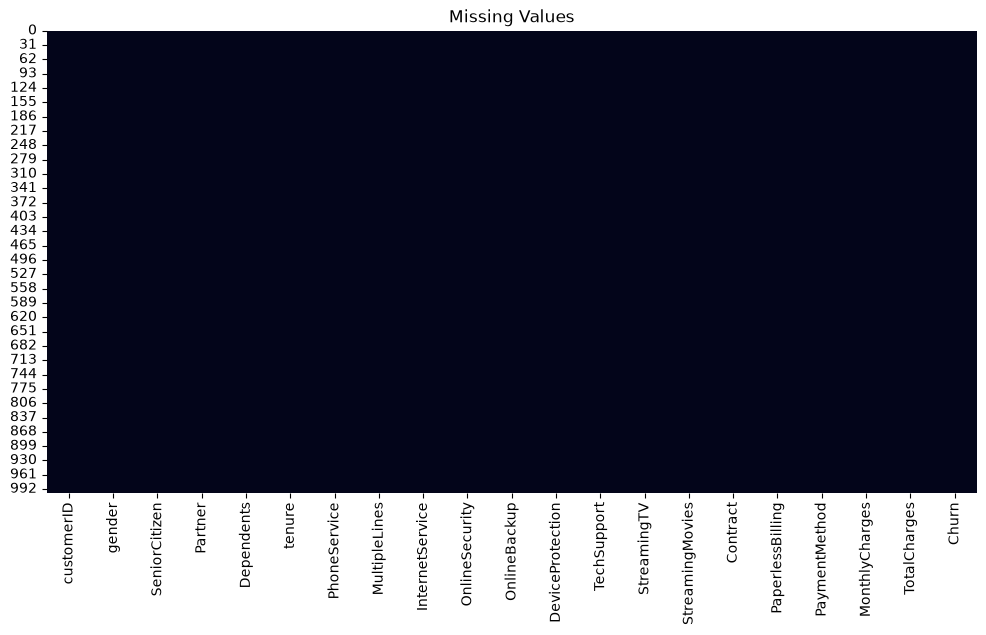

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        1
Churn               0
dtype: int64


In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(tele_data.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

print(tele_data.isnull().sum())

**Check Duplicates**

In [15]:
tele_data.duplicated().sum()

0

There are no duplicates values in the data set

**Check data types**

In [16]:
# Check Null and Dtypes
tele_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   str    
 1   gender            1000 non-null   str    
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   str    
 4   Dependents        1000 non-null   str    
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   str    
 7   MultipleLines     1000 non-null   str    
 8   InternetService   1000 non-null   str    
 9   OnlineSecurity    1000 non-null   str    
 10  OnlineBackup      1000 non-null   str    
 11  DeviceProtection  1000 non-null   str    
 12  TechSupport       1000 non-null   str    
 13  StreamingTV       1000 non-null   str    
 14  StreamingMovies   1000 non-null   str    
 15  Contract          1000 non-null   str    
 16  PaperlessBilling  1000 non-null   str    
 17  Payment

# Univariate Analysis

**Numerical column analysis**

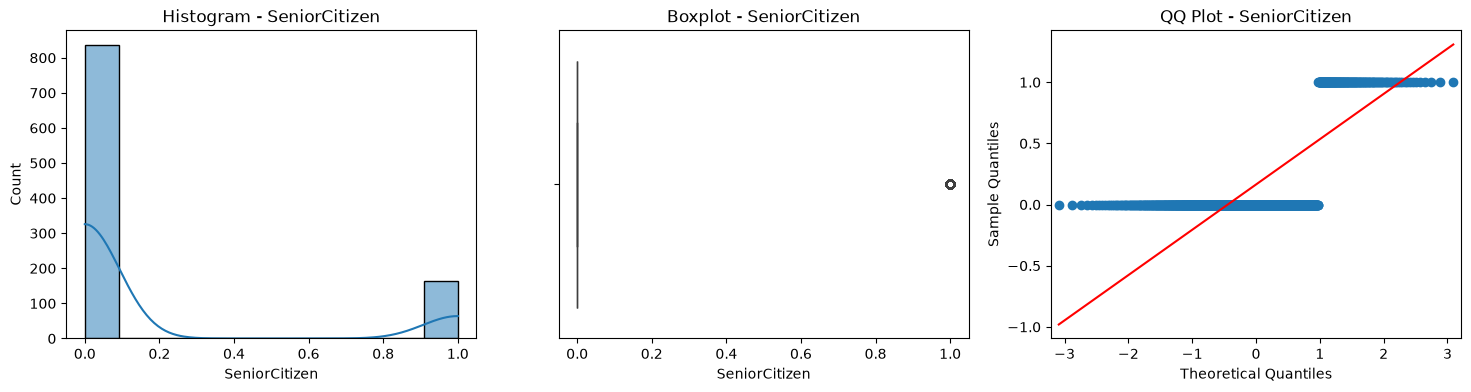

SeniorCitizen
Shapiro p-value = 5.770640841737732e-48
Not Normally Distributed


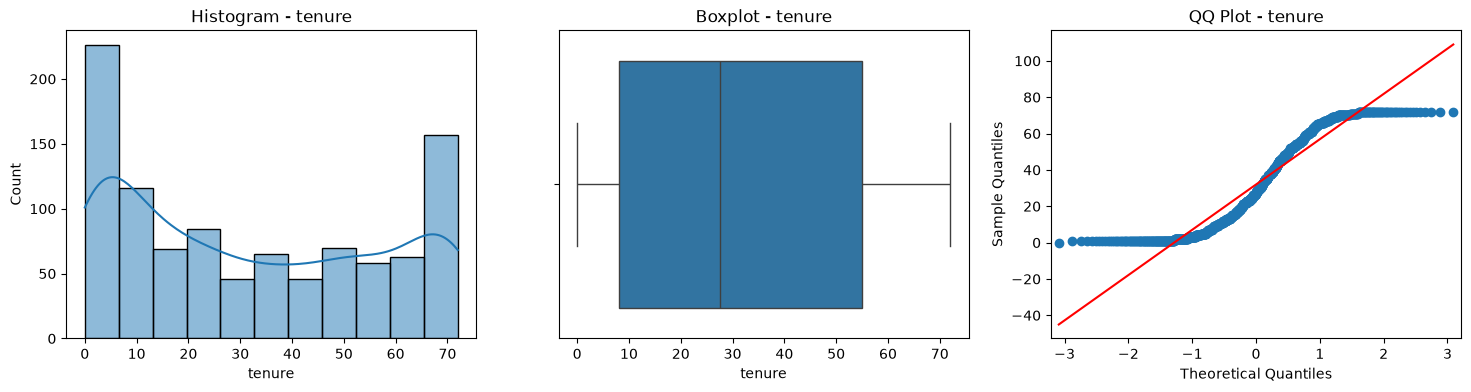

tenure
Shapiro p-value = 1.8886890279737583e-25
Not Normally Distributed


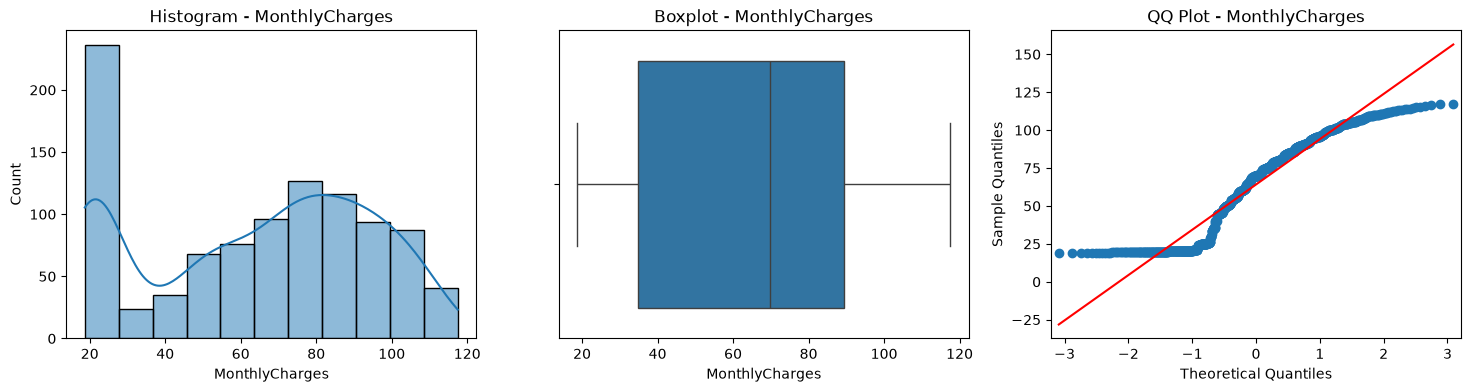

MonthlyCharges
Shapiro p-value = 1.3176261090531265e-22
Not Normally Distributed


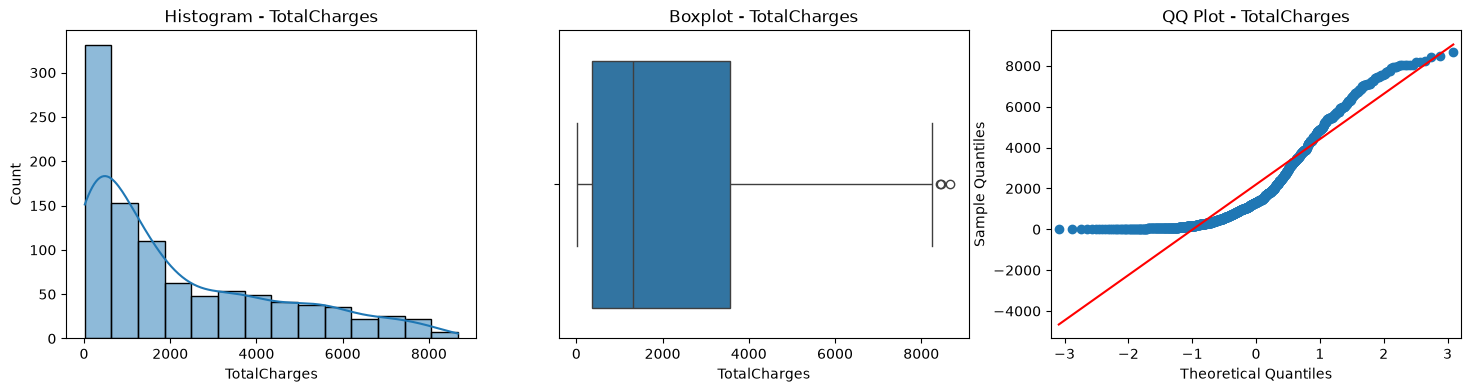

TotalCharges
Shapiro p-value = 2.4541004446238431e-29
Not Normally Distributed


In [17]:
for col in num_cols:

    fig, ax = plt.subplots(1,3, figsize=(18,4))

    sns.histplot(tele_data[col].dropna(), kde=True, ax=ax[0])
    ax[0].set_title(f'Histogram - {col}')

    sns.boxplot(x=tele_data[col], ax=ax[1])
    ax[1].set_title(f'Boxplot - {col}')

    qqplot(tele_data[col].dropna(),
           line='s',
           ax=ax[2])

    ax[2].set_title(f'QQ Plot - {col}')

    plt.show()

    stat, p = shapiro(tele_data[col].dropna())

    print(f"{col}")
    print(f"Shapiro p-value = {p}")

    if p > 0.05:
        print("Normally Distributed")
    else:
        print("Not Normally Distributed")

observation: here all numerical columns are not the normal distribution so we have to apply the log normal to make it normal distribution 2 and we have outliers only for the Totalcharges in this num_cols

**Categorical columns analysis**

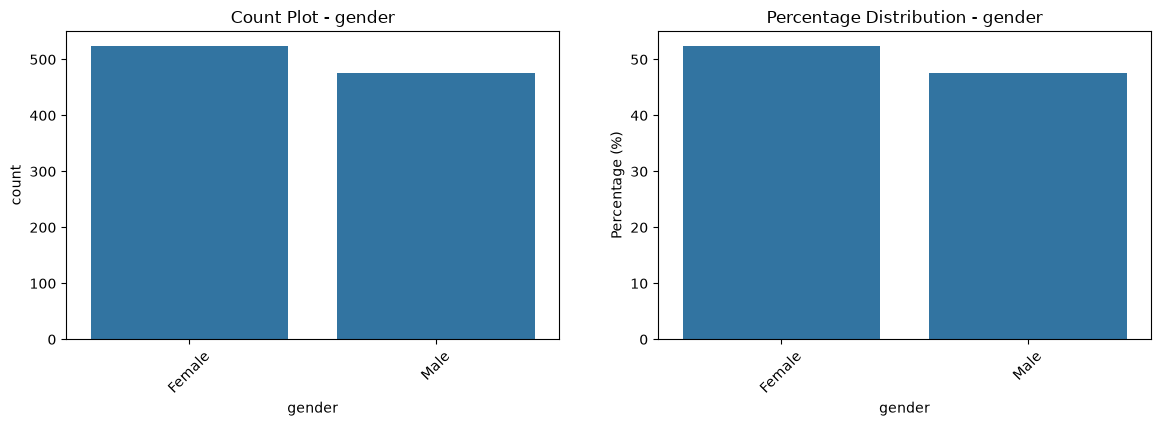


Column Name: gender
gender
Female    524
Male      476
Name: count, dtype: int64

Percentage:
gender
Female    52.4
Male      47.6
Name: proportion, dtype: float64
--------------------------------------------------


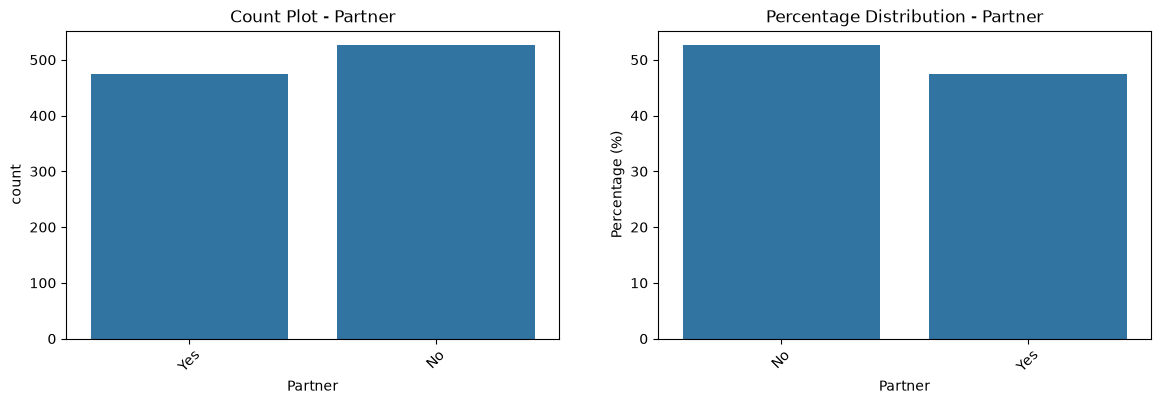


Column Name: Partner
Partner
No     526
Yes    474
Name: count, dtype: int64

Percentage:
Partner
No     52.6
Yes    47.4
Name: proportion, dtype: float64
--------------------------------------------------


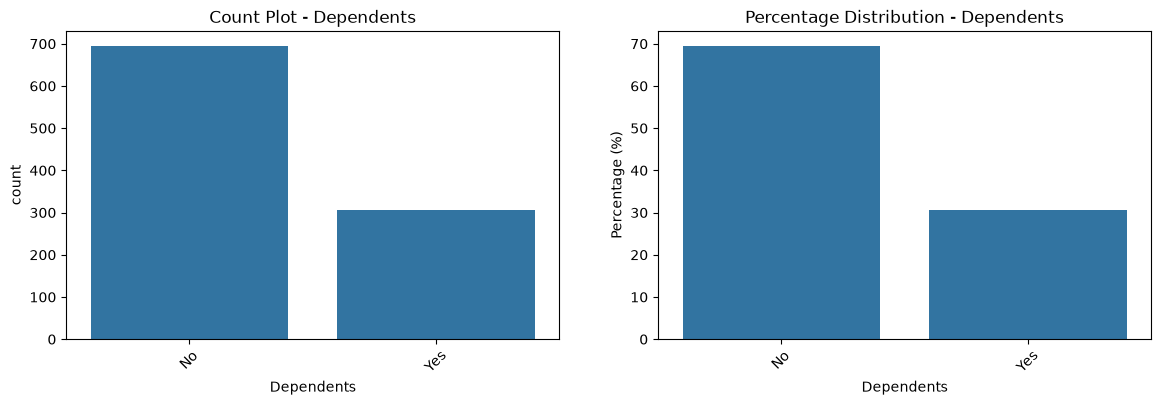


Column Name: Dependents
Dependents
No     695
Yes    305
Name: count, dtype: int64

Percentage:
Dependents
No     69.5
Yes    30.5
Name: proportion, dtype: float64
--------------------------------------------------


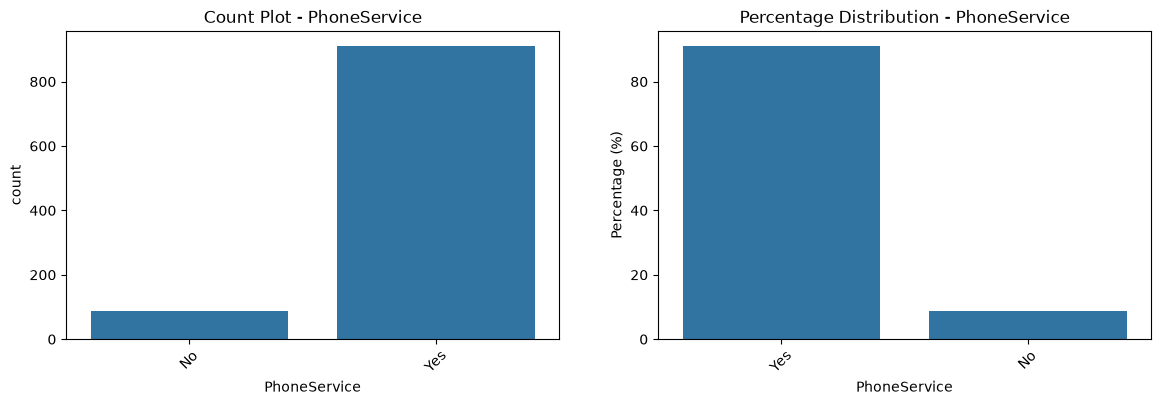


Column Name: PhoneService
PhoneService
Yes    911
No      89
Name: count, dtype: int64

Percentage:
PhoneService
Yes    91.1
No      8.9
Name: proportion, dtype: float64
--------------------------------------------------


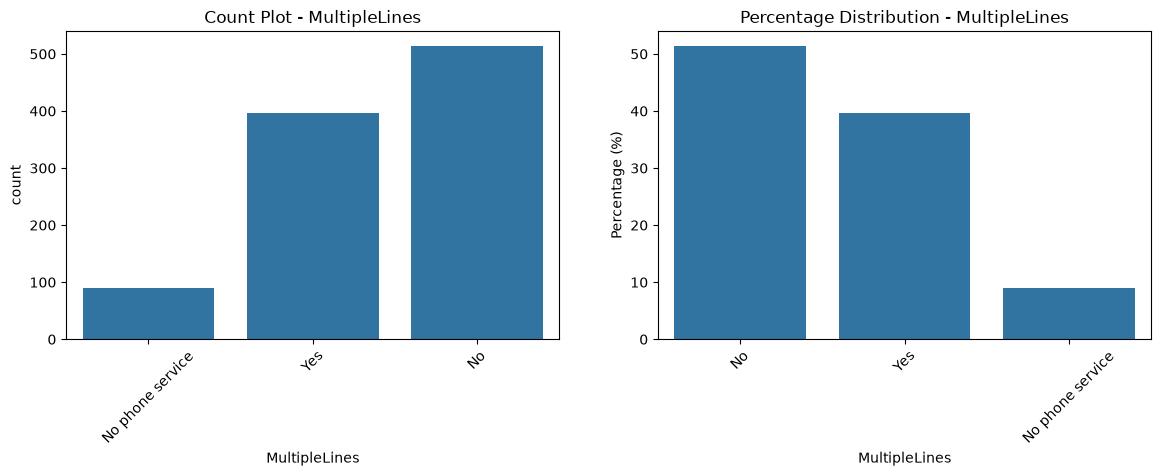


Column Name: MultipleLines
MultipleLines
No                  514
Yes                 397
No phone service     89
Name: count, dtype: int64

Percentage:
MultipleLines
No                  51.4
Yes                 39.7
No phone service     8.9
Name: proportion, dtype: float64
--------------------------------------------------


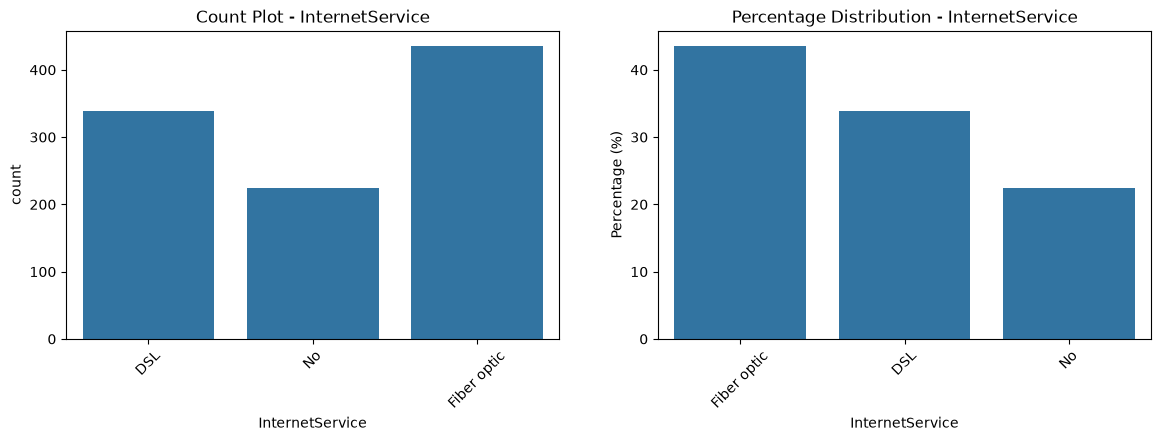


Column Name: InternetService
InternetService
Fiber optic    436
DSL            339
No             225
Name: count, dtype: int64

Percentage:
InternetService
Fiber optic    43.6
DSL            33.9
No             22.5
Name: proportion, dtype: float64
--------------------------------------------------


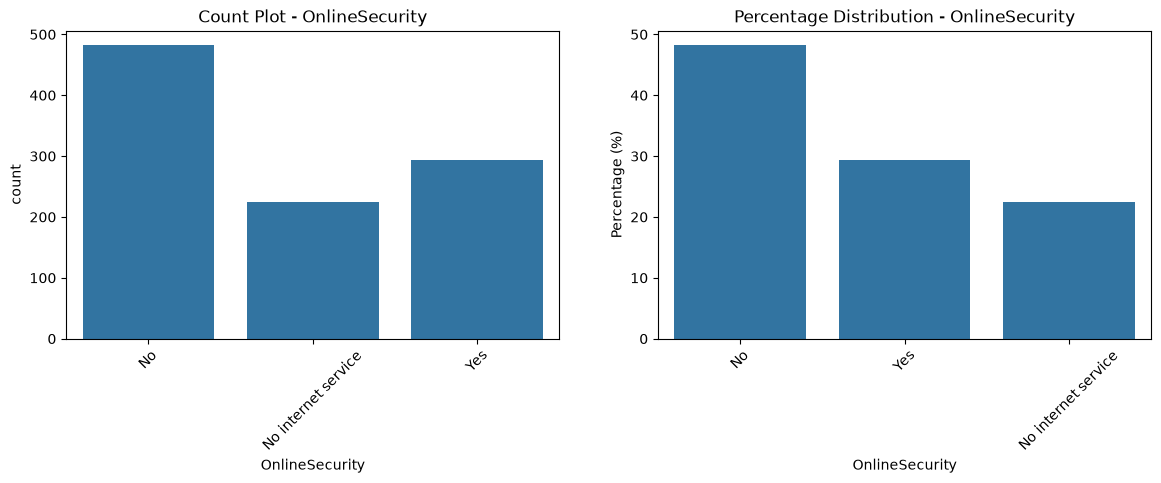


Column Name: OnlineSecurity
OnlineSecurity
No                     482
Yes                    293
No internet service    225
Name: count, dtype: int64

Percentage:
OnlineSecurity
No                     48.2
Yes                    29.3
No internet service    22.5
Name: proportion, dtype: float64
--------------------------------------------------


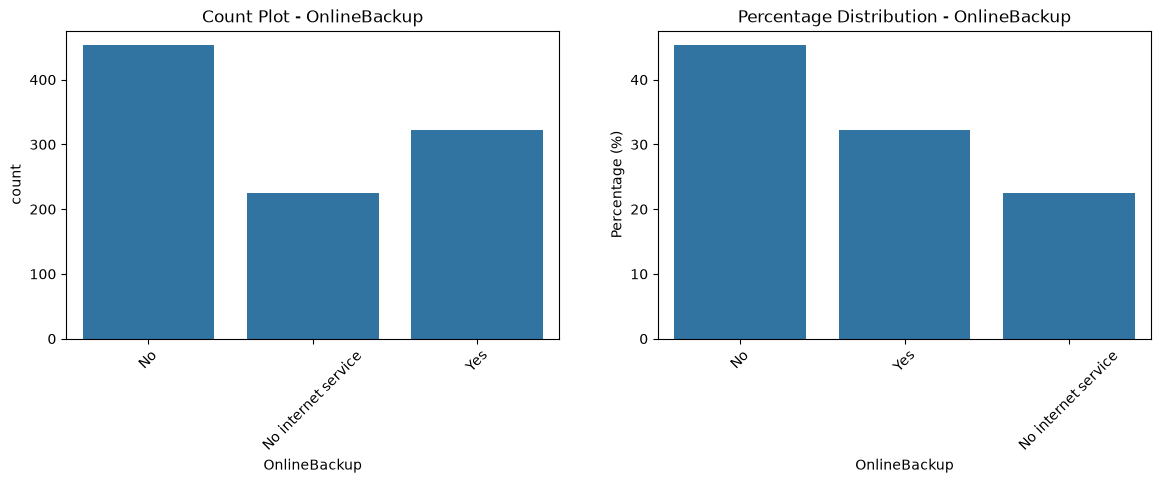


Column Name: OnlineBackup
OnlineBackup
No                     453
Yes                    322
No internet service    225
Name: count, dtype: int64

Percentage:
OnlineBackup
No                     45.3
Yes                    32.2
No internet service    22.5
Name: proportion, dtype: float64
--------------------------------------------------


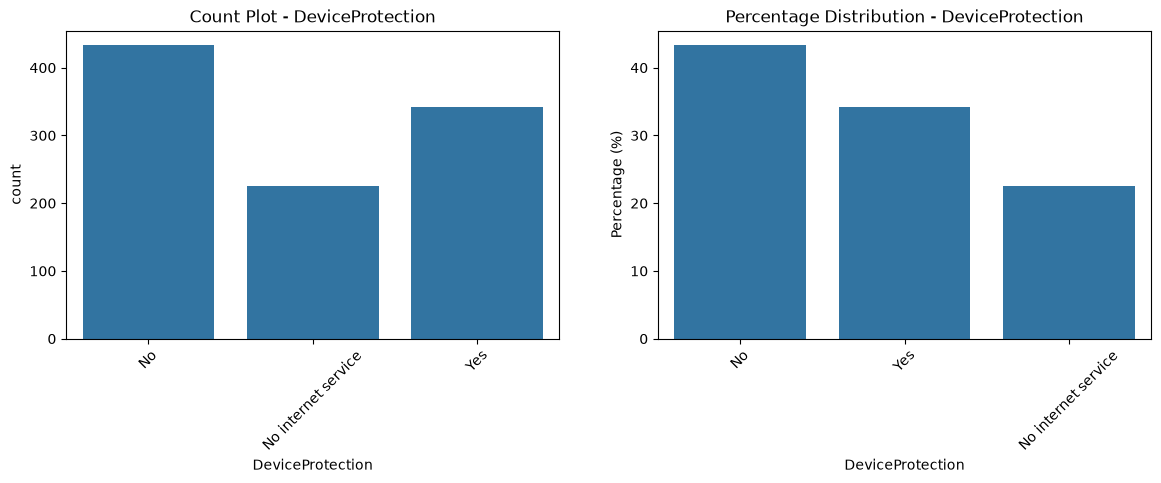


Column Name: DeviceProtection
DeviceProtection
No                     433
Yes                    342
No internet service    225
Name: count, dtype: int64

Percentage:
DeviceProtection
No                     43.3
Yes                    34.2
No internet service    22.5
Name: proportion, dtype: float64
--------------------------------------------------


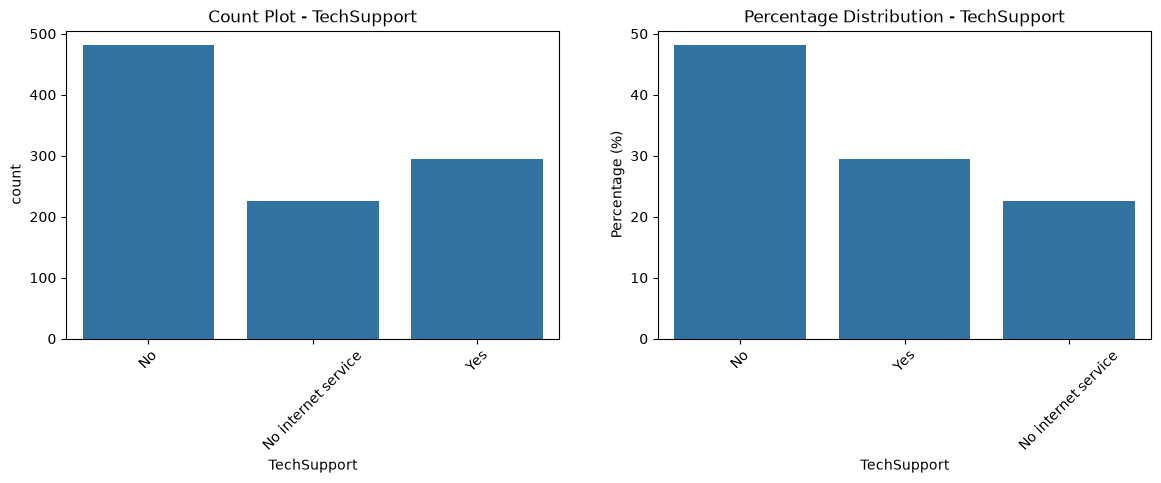


Column Name: TechSupport
TechSupport
No                     481
Yes                    294
No internet service    225
Name: count, dtype: int64

Percentage:
TechSupport
No                     48.1
Yes                    29.4
No internet service    22.5
Name: proportion, dtype: float64
--------------------------------------------------


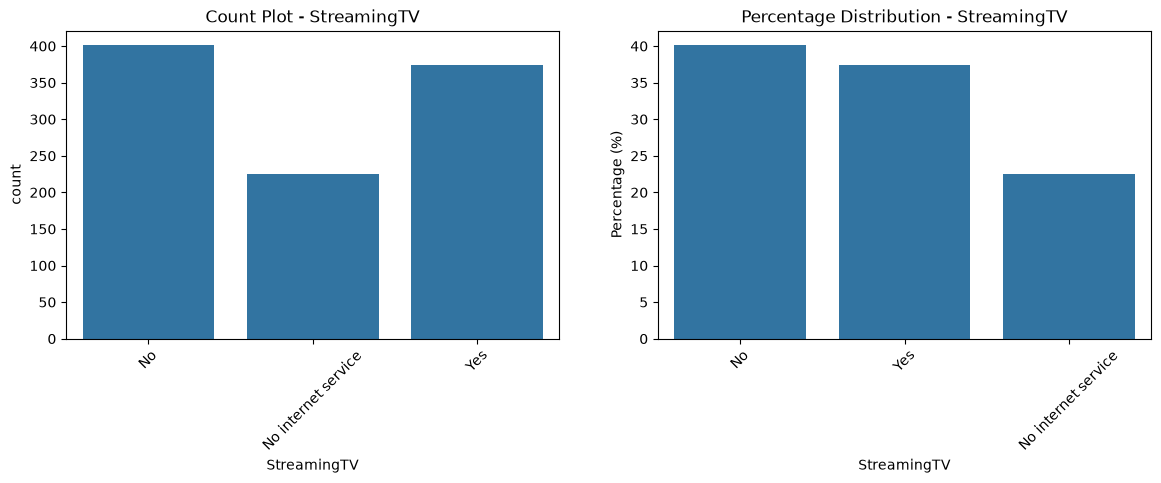


Column Name: StreamingTV
StreamingTV
No                     401
Yes                    374
No internet service    225
Name: count, dtype: int64

Percentage:
StreamingTV
No                     40.1
Yes                    37.4
No internet service    22.5
Name: proportion, dtype: float64
--------------------------------------------------


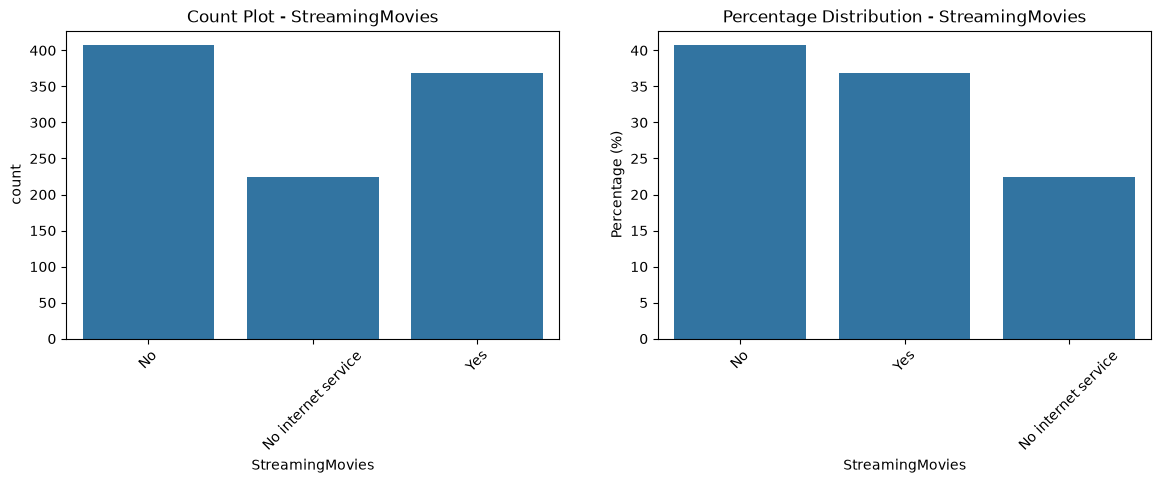


Column Name: StreamingMovies
StreamingMovies
No                     407
Yes                    368
No internet service    225
Name: count, dtype: int64

Percentage:
StreamingMovies
No                     40.7
Yes                    36.8
No internet service    22.5
Name: proportion, dtype: float64
--------------------------------------------------


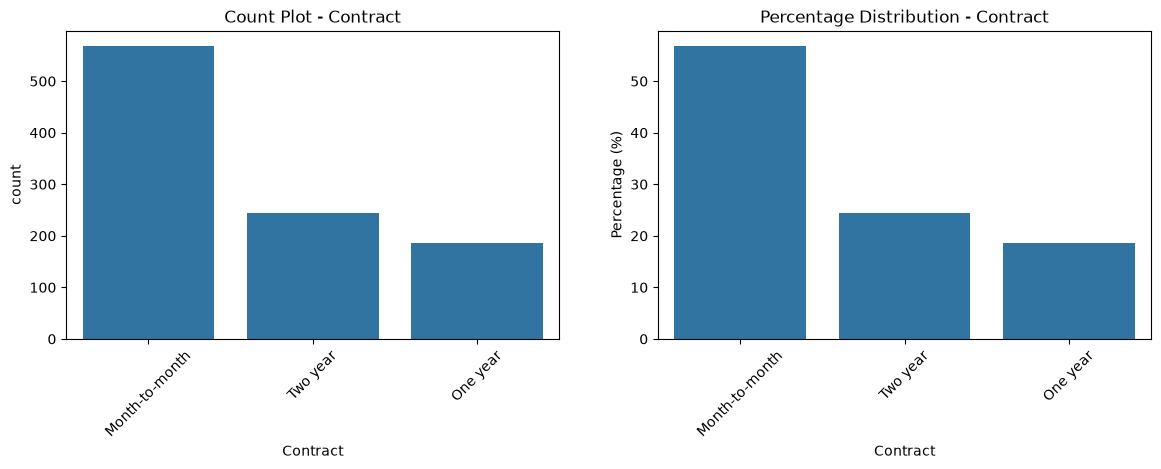


Column Name: Contract
Contract
Month-to-month    569
Two year          244
One year          187
Name: count, dtype: int64

Percentage:
Contract
Month-to-month    56.9
Two year          24.4
One year          18.7
Name: proportion, dtype: float64
--------------------------------------------------


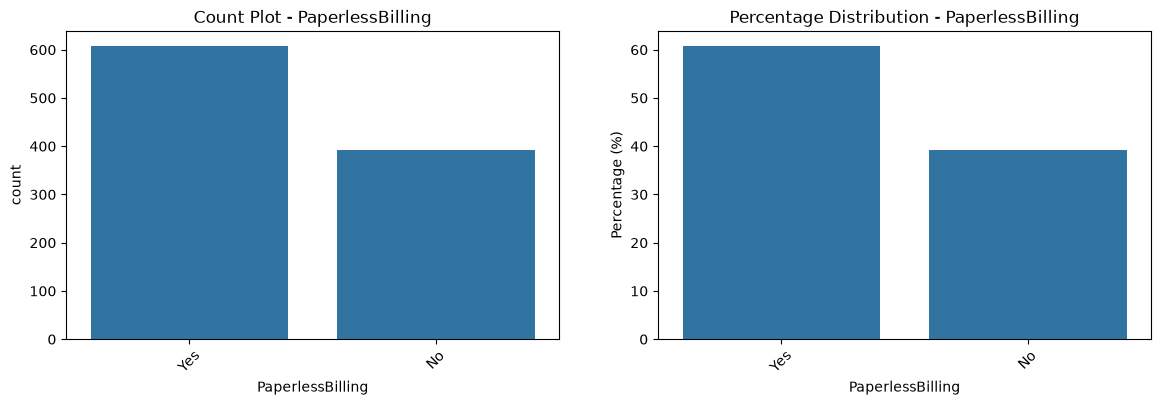


Column Name: PaperlessBilling
PaperlessBilling
Yes    608
No     392
Name: count, dtype: int64

Percentage:
PaperlessBilling
Yes    60.8
No     39.2
Name: proportion, dtype: float64
--------------------------------------------------


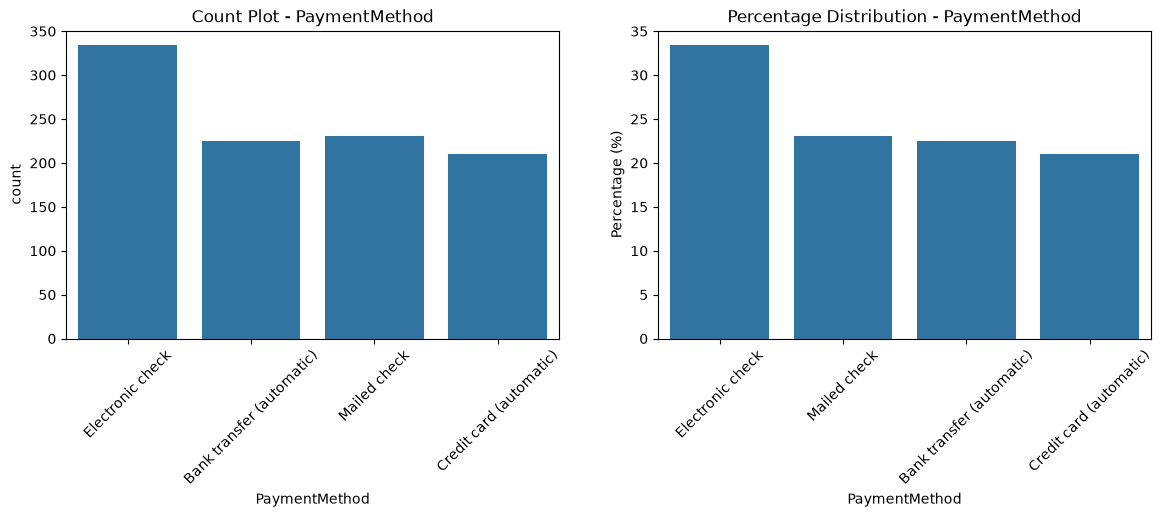


Column Name: PaymentMethod
PaymentMethod
Electronic check             334
Mailed check                 231
Bank transfer (automatic)    225
Credit card (automatic)      210
Name: count, dtype: int64

Percentage:
PaymentMethod
Electronic check             33.4
Mailed check                 23.1
Bank transfer (automatic)    22.5
Credit card (automatic)      21.0
Name: proportion, dtype: float64
--------------------------------------------------


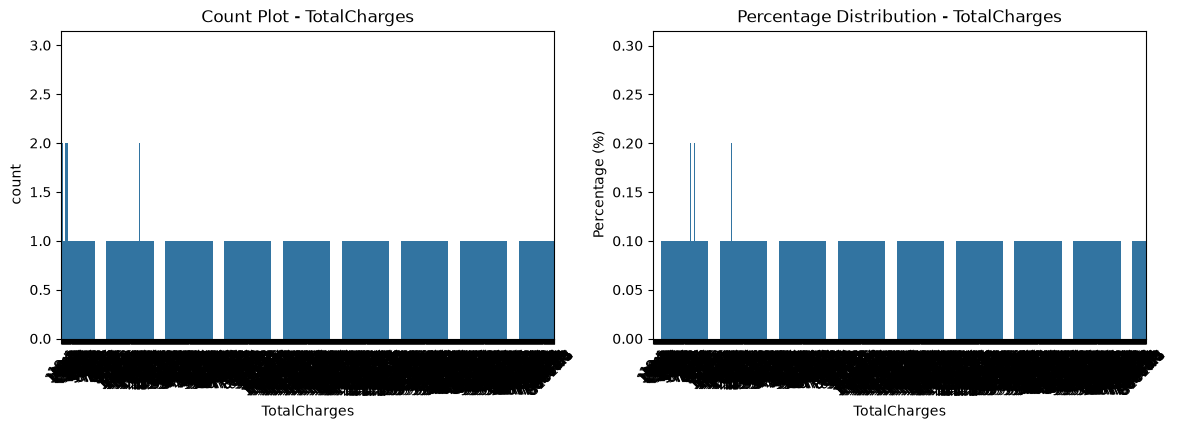


Column Name: TotalCharges
TotalCharges
19.45      3
20.00      3
19.65      3
74.50      2
19.50      2
          ..
383.65     1
2231.05    1
712.75     1
3175.85    1
1540.20    1
Name: count, Length: 978, dtype: int64

Percentage:
TotalCharges
19.45      0.3003
20.00      0.3003
19.65      0.3003
74.50      0.2002
19.50      0.2002
            ...  
383.65     0.1001
2231.05    0.1001
712.75     0.1001
3175.85    0.1001
1540.20    0.1001
Name: proportion, Length: 978, dtype: float64
--------------------------------------------------


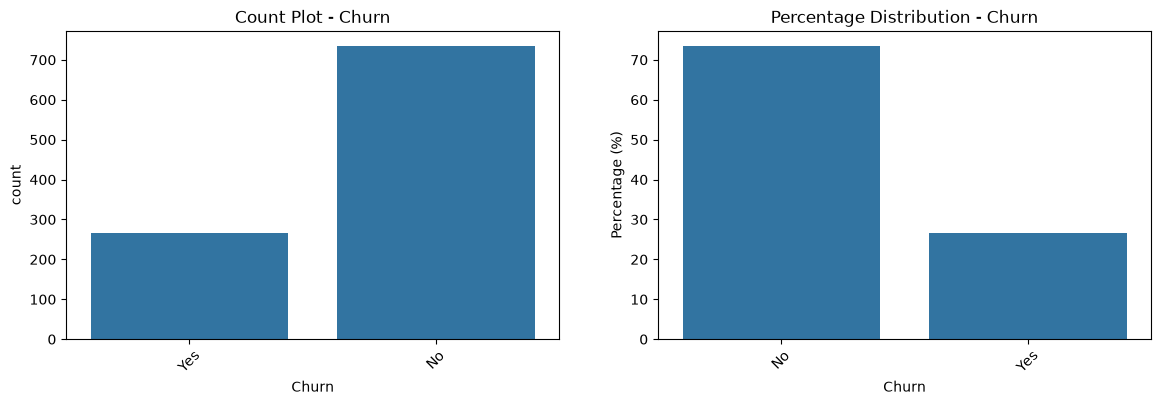


Column Name: Churn
Churn
No     735
Yes    265
Name: count, dtype: int64

Percentage:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64
--------------------------------------------------


In [18]:
cat_cols_without_id = [
    col for col in cat_cols
    if col != "customerID"]

for col in cat_cols_without_id:

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
                           
    # Count plot
    sns.countplot(
        x=tele_data[col],
        ax=ax[0]
    )

    ax[0].set_title(f'Count Plot - {col}')
    ax[0].tick_params(axis='x', rotation=45)

    # Percentage distribution

    value_counts = (
        tele_data[col]
        .value_counts(normalize=True)
        * 100
    )

    sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        ax=ax[1]
    )

    ax[1].set_title(
        f'Percentage Distribution - {col}'
    )

    ax[1].set_ylabel("Percentage (%)")
    ax[1].tick_params(axis='x', rotation=45)


    plt.show()

    print(f"\nColumn Name: {col}")
    print(tele_data[col].value_counts())

    print("\nPercentage:")
    print(
        tele_data[col]
        .value_counts(normalize=True)
        * 100
    )

    print("-"*50)

Observation:

- Most categorical features are not highly imbalanced except some service-related columns.
- Contract, InternetService, PaymentMethod may have strong impact on churn prediction.
- Churn target is imbalanced with 26.5% churned customers and 73.5% retained customers.
    - Customer stayed with company  = 73.5%
    - Customer left company         = 26.5%
- Categorical features require encoding before model training.

# BIVARIATE ANALYSIS

**Numerical vs Churn**

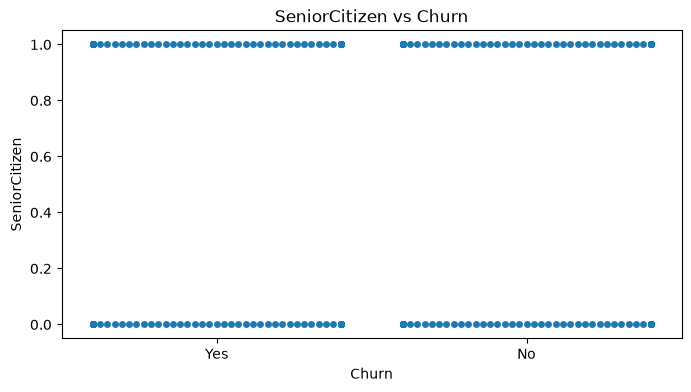

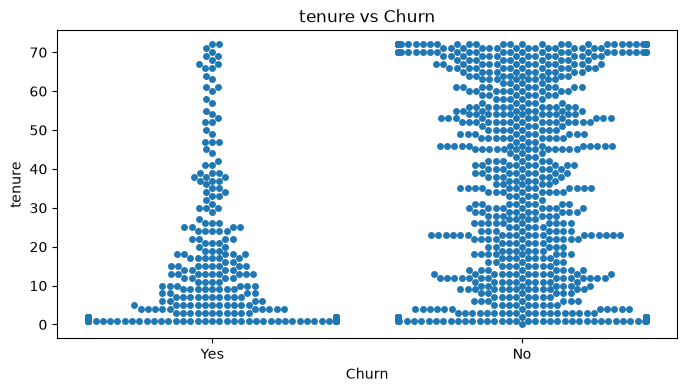

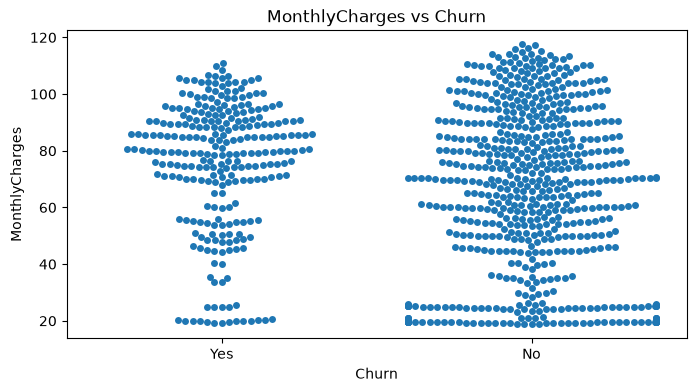

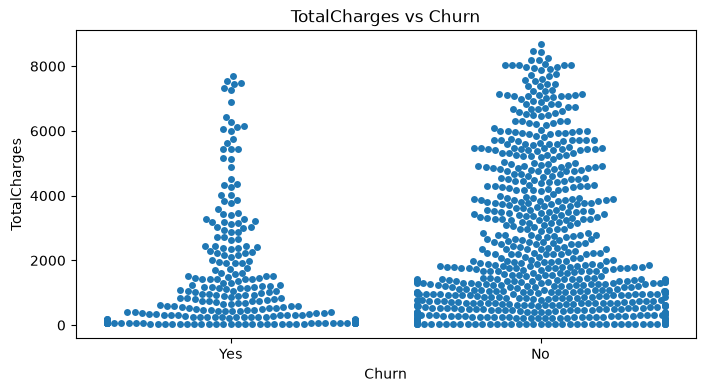

In [19]:
for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.swarmplot(
        data=tele_data,
        x='Churn',
        y=col
    )

    plt.title(f'{col} vs Churn')
    plt.show()


- X-axis → Churn
- Yes = customers who left
- No = customers who stayed
- Y-axis → TotalCharges

**TotalCharges**
- TotalCharges contains some outliers, mainly among churned customers.These values represent high-value customers who discontinued services

**MonthlyCharges**
- MonthlyCharges shows some relationship with churn, where some customers with higher monthly charges are present in the churn group. However, there is significant overlap between churned(yes) and retained customers(no), indicating that monthly charges alone may not be a strong predictor of churn. Some customers continue using the service despite higher charges, while some customers leave even with lower monthly charges.

**SeniorCitizens**
- seniorcitizens they 90% left the company and this column is not high relationship with churn

**Tenure**
- Tenure shows a strong relationship with churn. Customers with lower tenure (0–20 months contract) have a higher tendency to churn(yes/leaving company), indicating that new customers are more likely to leave. Long-term customers generally remain with the company;

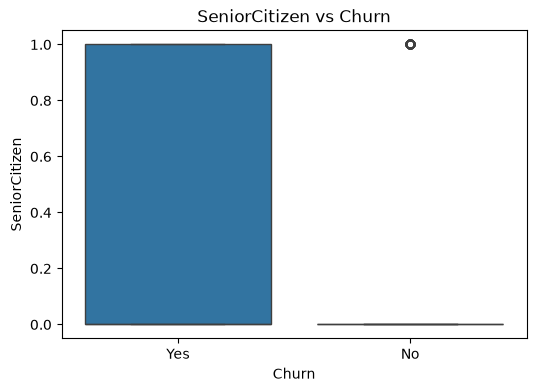

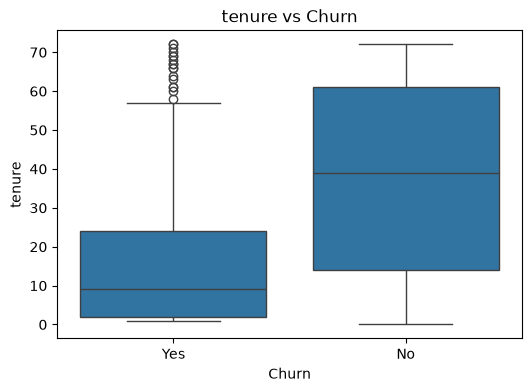

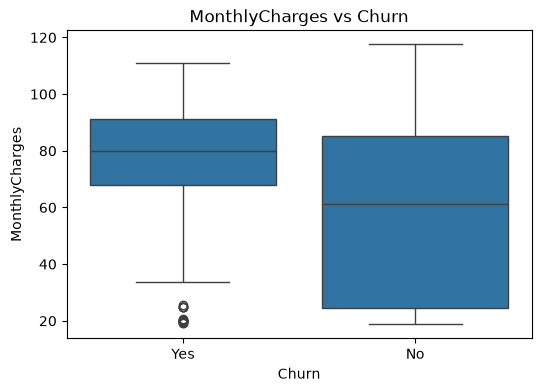

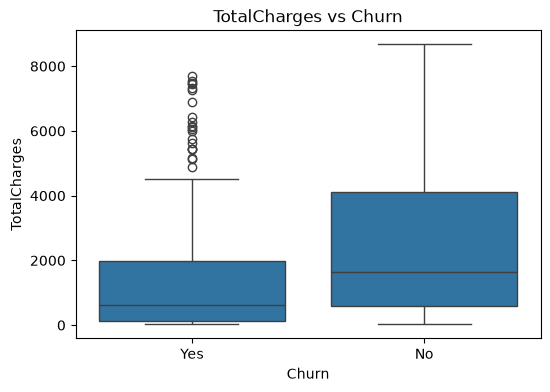

In [20]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="Churn",
        y=col,
        data=tele_data
    )

    plt.title(f"{col} vs Churn")

    plt.show()

**Categorical vs Churn**

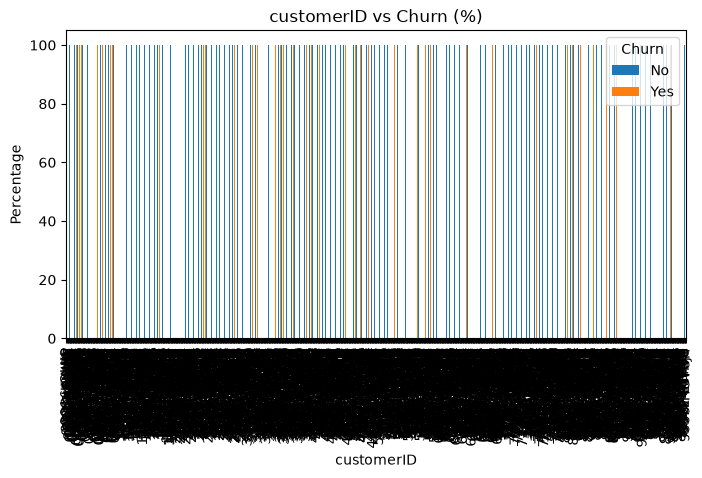

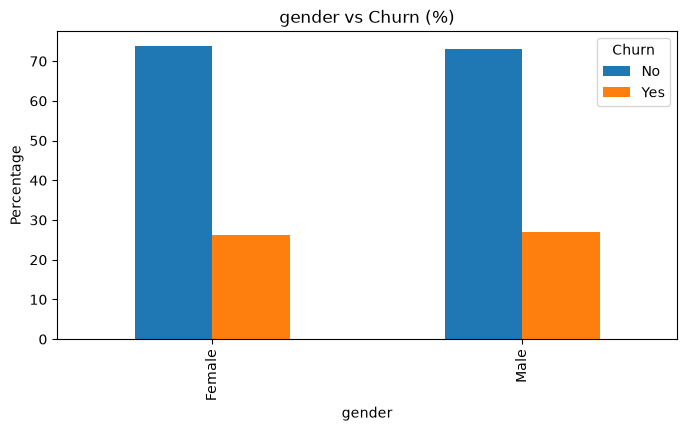

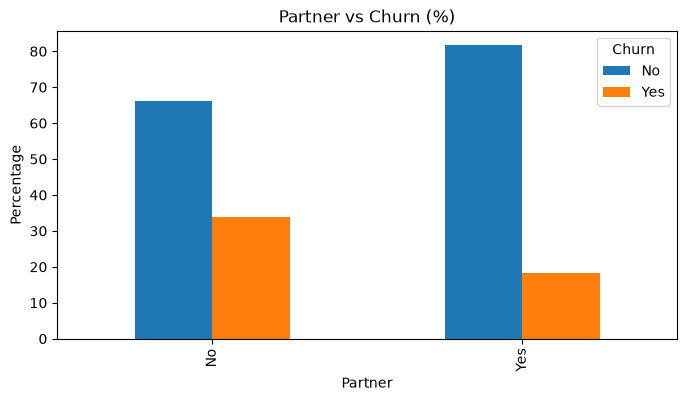

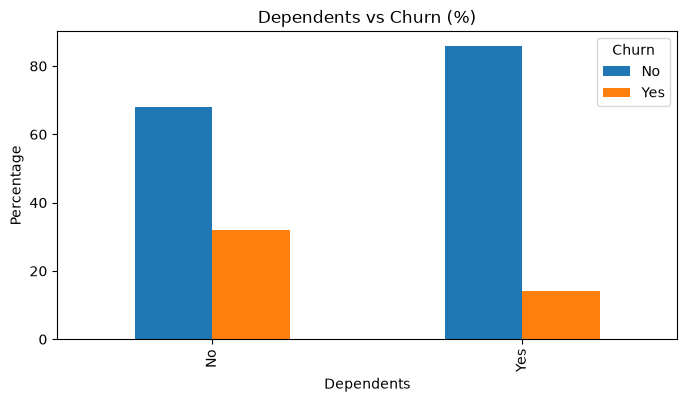

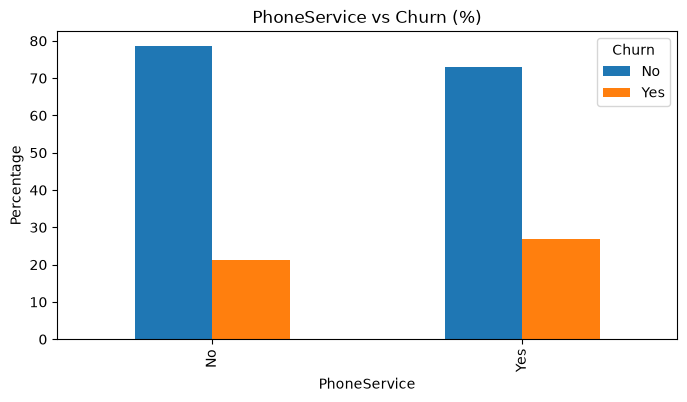

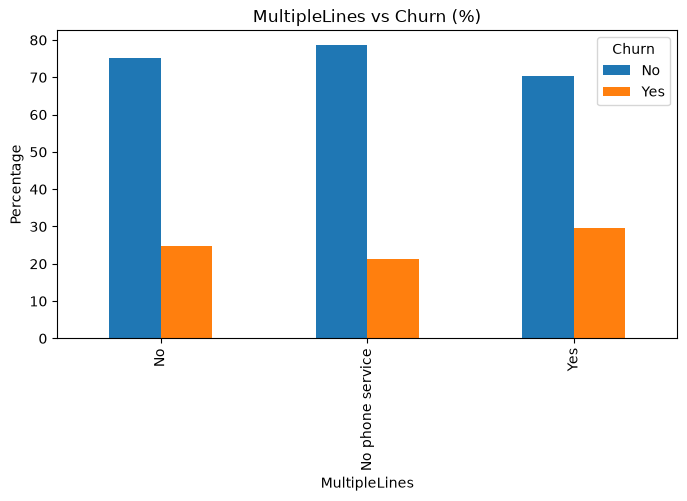

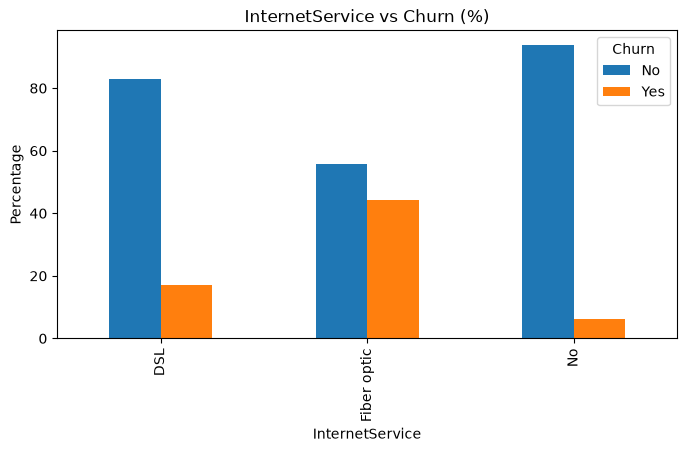

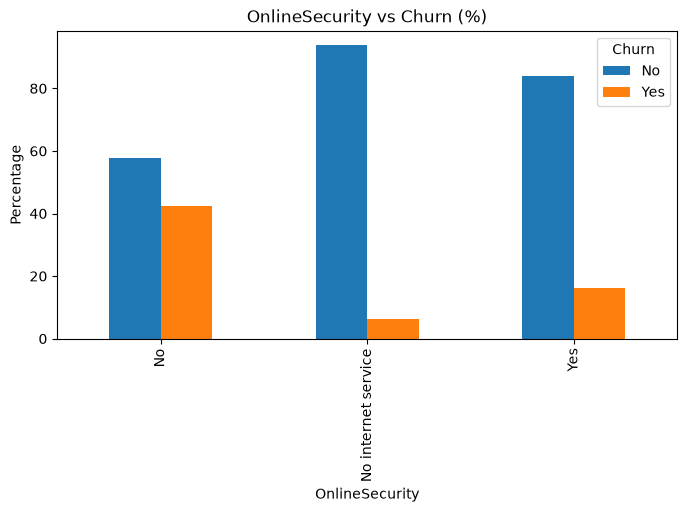

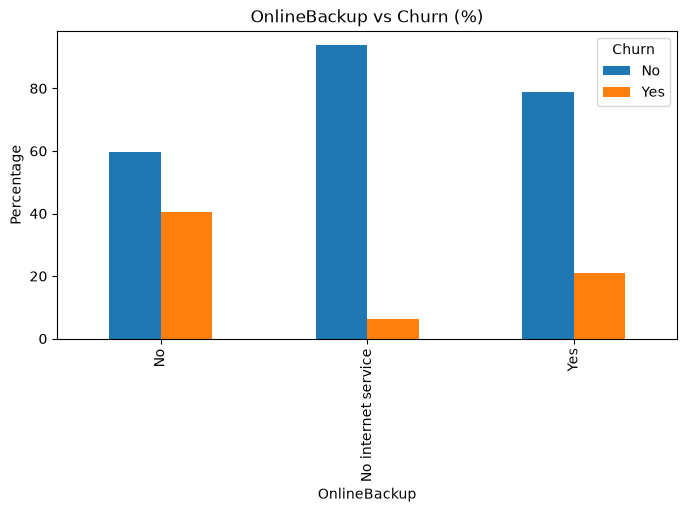

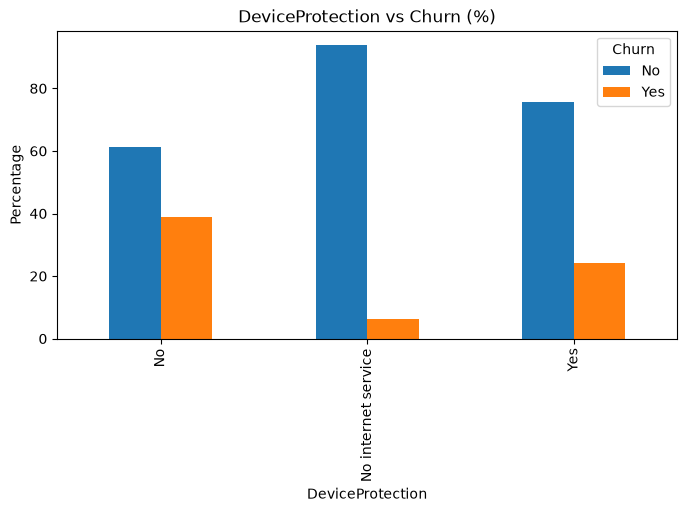

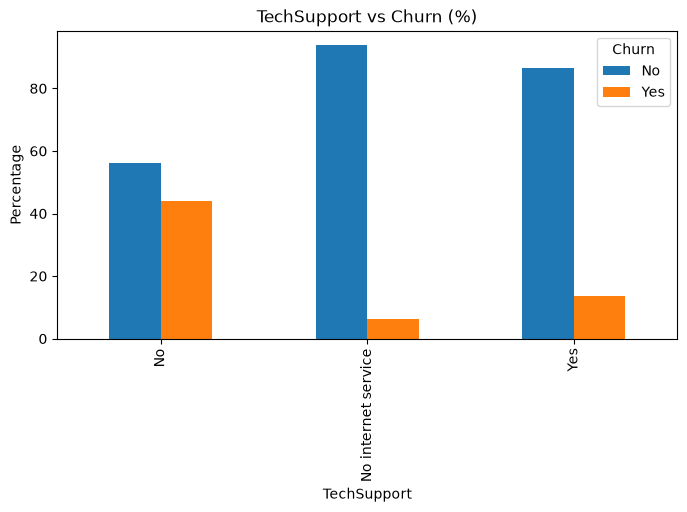

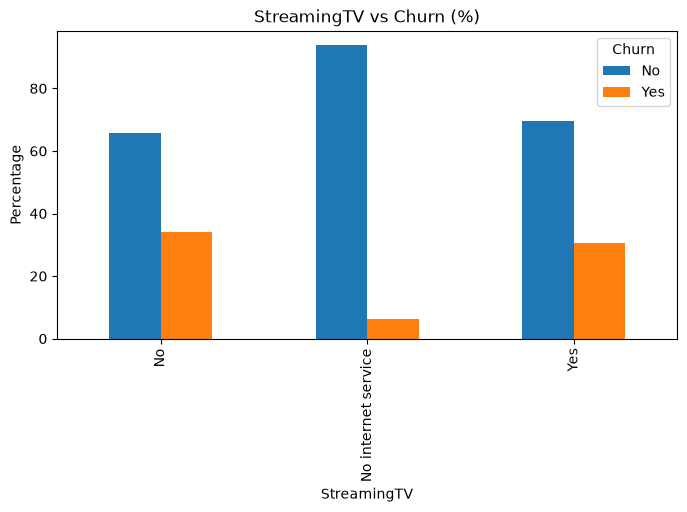

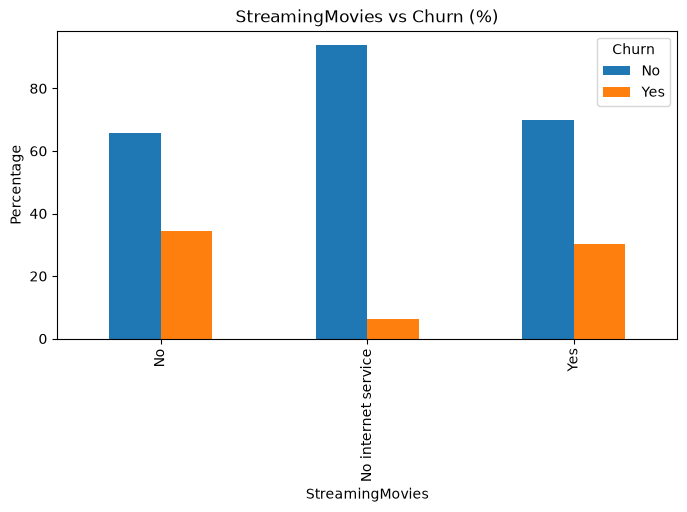

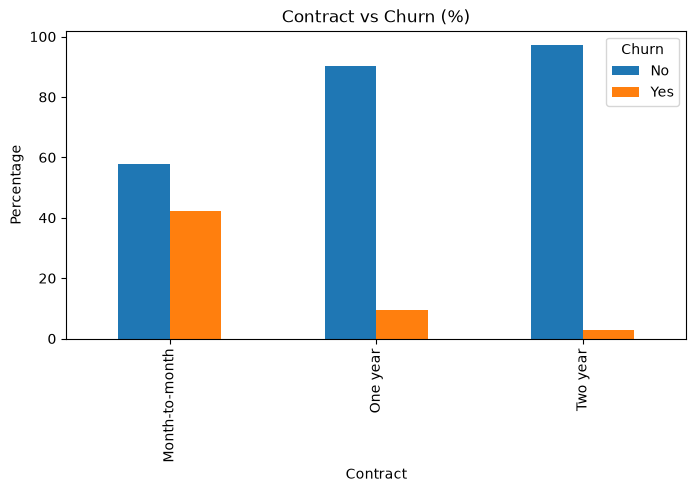

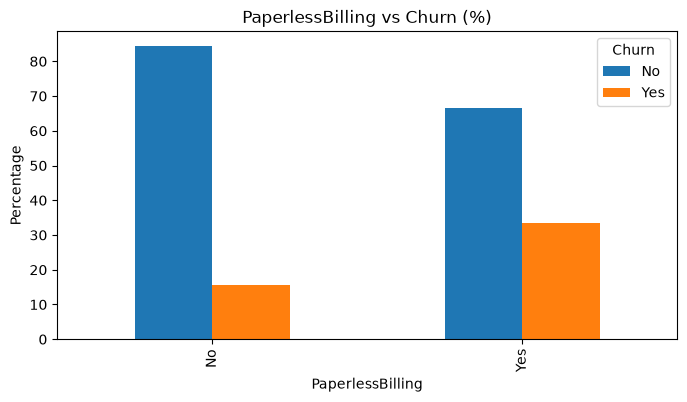

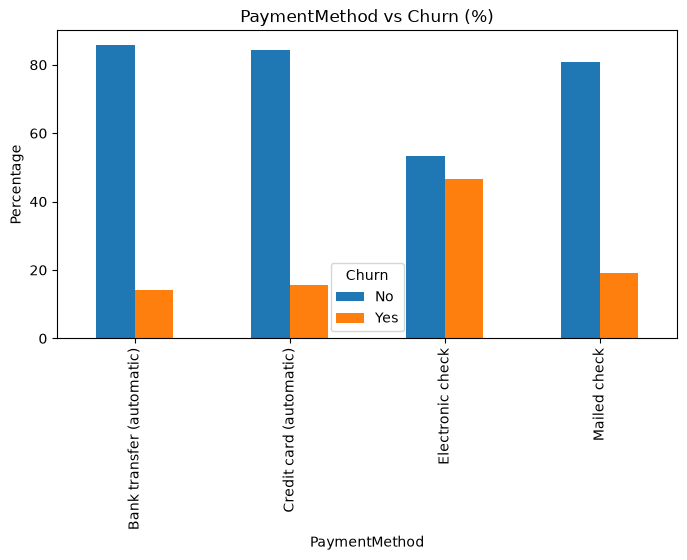

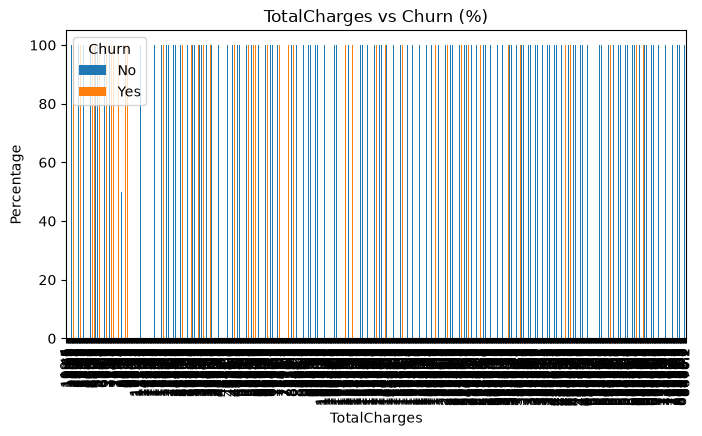

In [21]:
for col in cat_cols:

    if col != 'Churn':

        cross = pd.crosstab(
            tele_data[col],
            tele_data['Churn'],
            normalize='index'
        ) * 100

        cross.plot(
            kind='bar',
            figsize=(8,4)
        )

        plt.title(f'{col} vs Churn (%)')

        plt.ylabel('Percentage')

        plt.show()

Observations:
- Based on categorical analysis, features such as Contract, PaymentMethod, InternetService, OnlineSecurity, OnlineBackup, and DeviceProtection show noticeable differences between churn and non-churn customers. Gender and PhoneService show minimal impact. Month-to-month contracts and electronic check payment methods appear to be associated with higher churn.

# MUTIVARIATE ANALYSIS USING PAIRPLOT

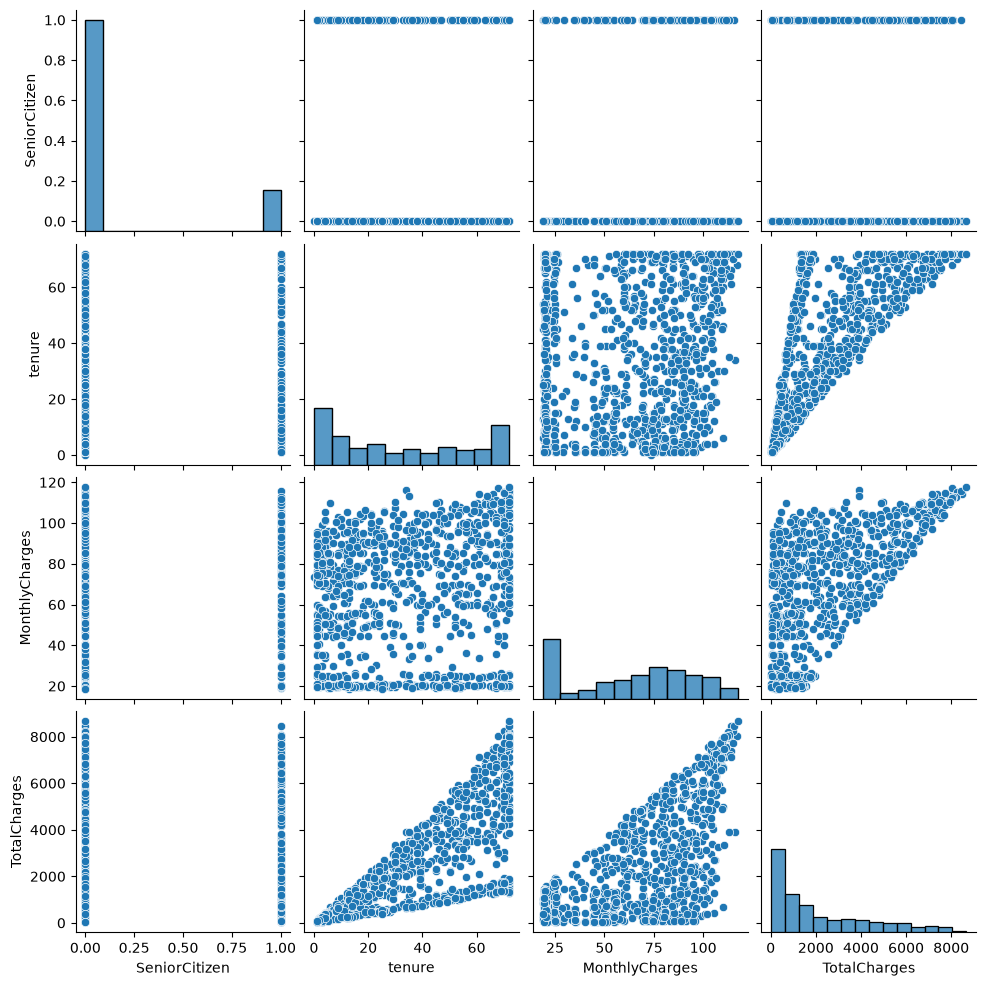

In [ ]:

sns.pairplot(
    tele_data[num_cols]
)

plt.show()

Observations:
- Multivariate analysis using pairplot shows that TotalCharges has a strong positive relationship with tenure and MonthlyCharges.
- As tenure increases, TotalCharges also increases because customers who stay longer contribute more total revenue.
- MonthlyCharges also shows a positive relationship with TotalCharges.
- However, tenure and MonthlyCharges do not show a strong relationship.
- SeniorCitizen is a binary feature, so pairplot interpretation is limited.